In [1]:
# Project 6 - Wine Quality Prediction
# Step 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ayesha09q/wine-quality-dataset/WineQT.csv


In [3]:
# Step 3 - Load Dataset
df = pd.read_csv('/kaggle/input/datasets/ayesha09q/wine-quality-dataset/WineQT.csv')
print("Data loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Data loaded successfully!
Shape: (1143, 13)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4      

In [4]:
# Step 4 - Explore & Clean Data
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Wine Quality Distribution ===")
print(df['quality'].value_counts())

# Convert quality to Good (1) or Bad (0)
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)

print("\n=== Good vs Bad Wine ===")
print(df['quality_label'].value_counts())
print("0 = Bad Wine, 1 = Good Wine")

=== Missing Values ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

=== Wine Quality Distribution ===
quality
5    483
6    462
7    143
4     33
8     16
3      6
Name: count, dtype: int64

=== Good vs Bad Wine ===
quality_label
1    621
0    522
Name: count, dtype: int64
0 = Bad Wine, 1 = Good Wine


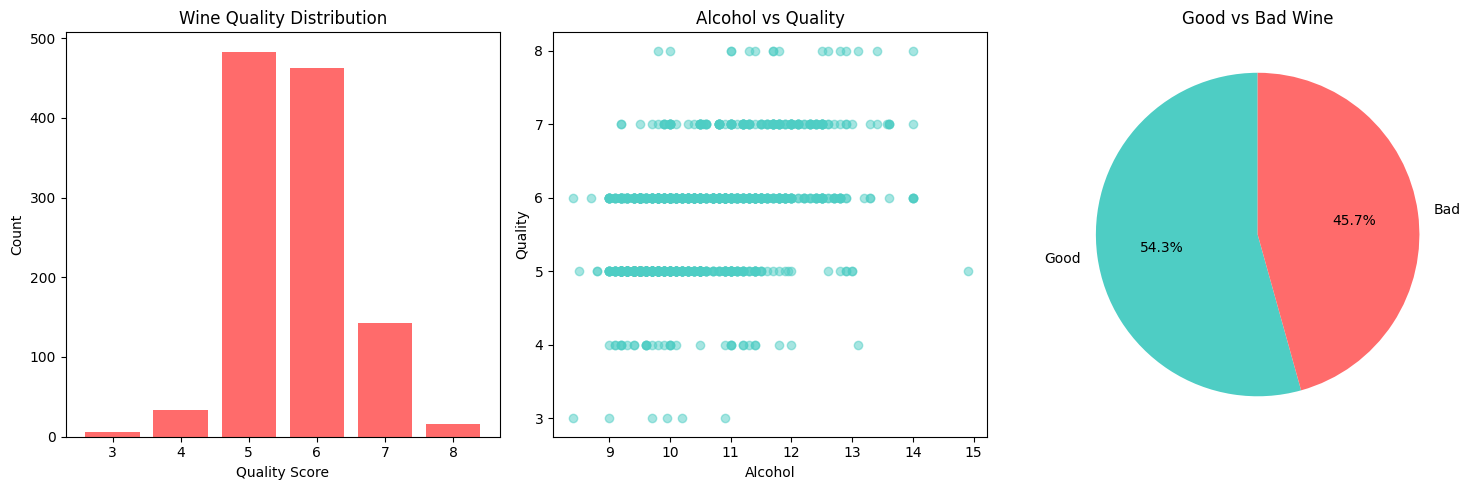

In [5]:
# Step 5 - Visualize Data
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Quality Distribution
axes[0].bar(df['quality'].value_counts().index,
            df['quality'].value_counts().values,
            color='#FF6B6B')
axes[0].set_title('Wine Quality Distribution')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')

# Alcohol vs Quality
axes[1].scatter(df['alcohol'], df['quality'],
                color='#4ECDC4', alpha=0.5)
axes[1].set_title('Alcohol vs Quality')
axes[1].set_xlabel('Alcohol')
axes[1].set_ylabel('Quality')

# Good vs Bad Pie
axes[2].pie([621, 522], labels=['Good', 'Bad'],
            colors=['#4ECDC4', '#FF6B6B'],
            autopct='%1.1f%%', startangle=90)
axes[2].set_title('Good vs Bad Wine')

plt.tight_layout()
plt.show()

In [6]:
# Step 6 - Train 3 Models
# Prepare data
X = df.drop(['quality', 'quality_label', 'Id'], axis=1)
y = df['quality_label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Model 1 - Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# Model 2 - SGD
sgd_model = SGDClassifier(random_state=42)
sgd_model.fit(X_train, y_train)
sgd_pred = sgd_model.predict(X_test)
sgd_acc = accuracy_score(y_test, sgd_pred)

# Model 3 - SVC
svc_model = SVC(random_state=42)
svc_model.fit(X_train, y_train)
svc_pred = svc_model.predict(X_test)
svc_acc = accuracy_score(y_test, svc_pred)

print(f"Random Forest Accuracy:  {rf_acc*100:.2f}%")
print(f"SGD Accuracy:            {sgd_acc*100:.2f}%")
print(f"SVC Accuracy:            {svc_acc*100:.2f}%")

Random Forest Accuracy:  76.42%
SGD Accuracy:            53.28%
SVC Accuracy:            68.12%


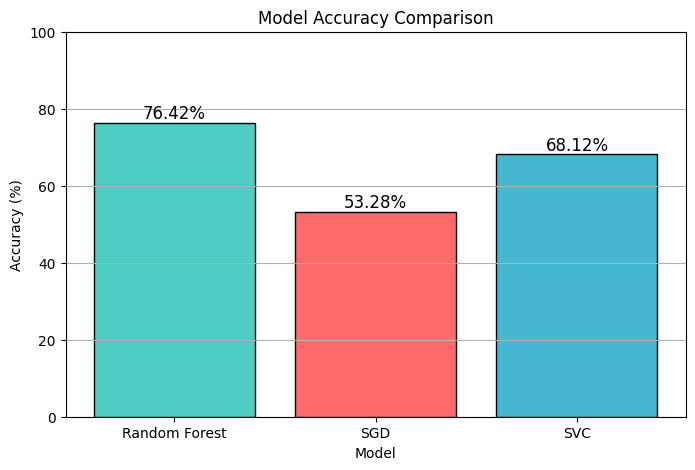

In [7]:
# Step 7 - Compare Models
models = ['Random Forest', 'SGD', 'SVC']
accuracies = [76.42, 53.28, 68.12]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, 
               color=['#4ECDC4', '#FF6B6B', '#45B7D1'],
               edgecolor='black')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 1,
             f'{acc}%', ha='center', fontsize=12)

plt.grid(axis='y')
plt.show()

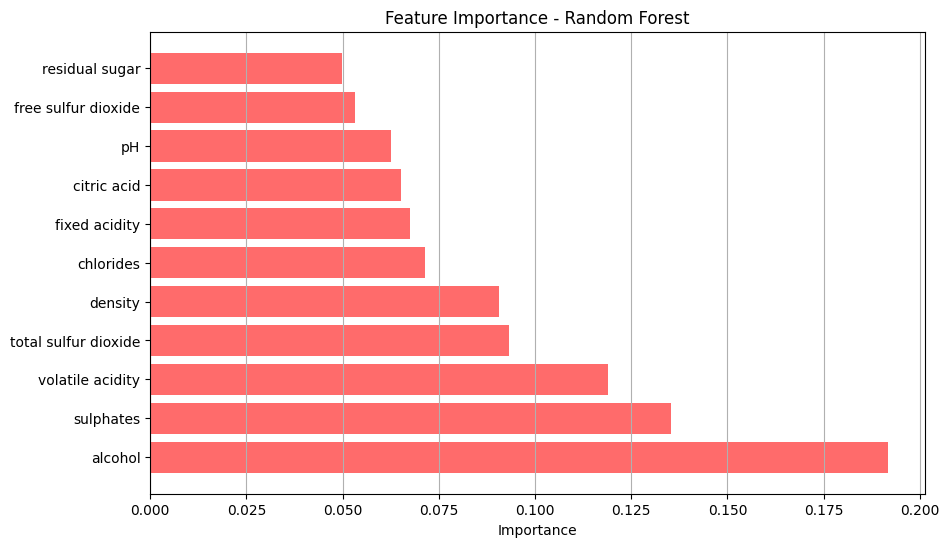

                 Feature  Importance
10               alcohol    0.191771
9              sulphates    0.135358
1       volatile acidity    0.119015
6   total sulfur dioxide    0.093319
7                density    0.090676
4              chlorides    0.071366
0          fixed acidity    0.067597
2            citric acid    0.065265
8                     pH    0.062583
5    free sulfur dioxide    0.053313
3         residual sugar    0.049736


In [8]:
# Step 8 - Feature Importance (Random Forest)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'],
         feature_importance['Importance'],
         color='#FF6B6B')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.grid(axis='x')
plt.show()

print(feature_importance)

In [9]:
# Step 9 - Final Summary
print("=" * 55)
print("     WINE QUALITY PREDICTION - SUMMARY")
print("=" * 55)

print(f"\n Total Wines Analyzed: {len(df)}")
print(f" Good Wines: 621 (54.3%)")
print(f" Bad Wines: 522 (45.7%)")

print("\n=== MODEL PERFORMANCE ===")
print(f" Random Forest: 76.42% ✅ Best Model")
print(f" SVC:           68.12%")
print(f" SGD:           53.28%")

print("\n=== KEY FINDINGS ===")
print(" 1. Alcohol is most important factor")
print(" 2. Sulphates affect quality greatly")
print(" 3. Volatile acidity hurts quality")
print(" 4. Random Forest best for prediction")

print("\n=== RECOMMENDATIONS ===")
print(" 1. Higher alcohol content = better quality")
print(" 2. Control volatile acidity in production")
print(" 3. Use Random Forest for wine classification")
print(" 4. Collect more data for better accuracy")
print("=" * 55)
print(" Wine Quality Prediction Completed!")
print("=" * 55)

     WINE QUALITY PREDICTION - SUMMARY

 Total Wines Analyzed: 1143
 Good Wines: 621 (54.3%)
 Bad Wines: 522 (45.7%)

=== MODEL PERFORMANCE ===
 Random Forest: 76.42% ✅ Best Model
 SVC:           68.12%
 SGD:           53.28%

=== KEY FINDINGS ===
 1. Alcohol is most important factor
 2. Sulphates affect quality greatly
 3. Volatile acidity hurts quality
 4. Random Forest best for prediction

=== RECOMMENDATIONS ===
 1. Higher alcohol content = better quality
 2. Control volatile acidity in production
 3. Use Random Forest for wine classification
 4. Collect more data for better accuracy
 Wine Quality Prediction Completed!
